In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [118]:
df = pd.read_csv("Datasets\\raw\\Dataset.csv")

In [119]:
df.shape

(1552210, 44)

In [120]:
"""
Removing columns "Unnamed: 0" and "SepsisLabel" 
because "Unnamed: 0" is duplicate of the column "Hour" and 
"SepsisLabel" is target column not any feature
"""
columns_to_drop = ['Unnamed: 0', 'SepsisLabel']
df = df.drop(columns=columns_to_drop)
df.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,17072


In [121]:
"""Graphical analysis of whole data frame before pre-processing"""

'Graphical analysis of whole data frame before pre-processing'

In [122]:
# Heatmap of dataset before pre-processing
# sns.heatmap(df.isnull(), cbar=False)

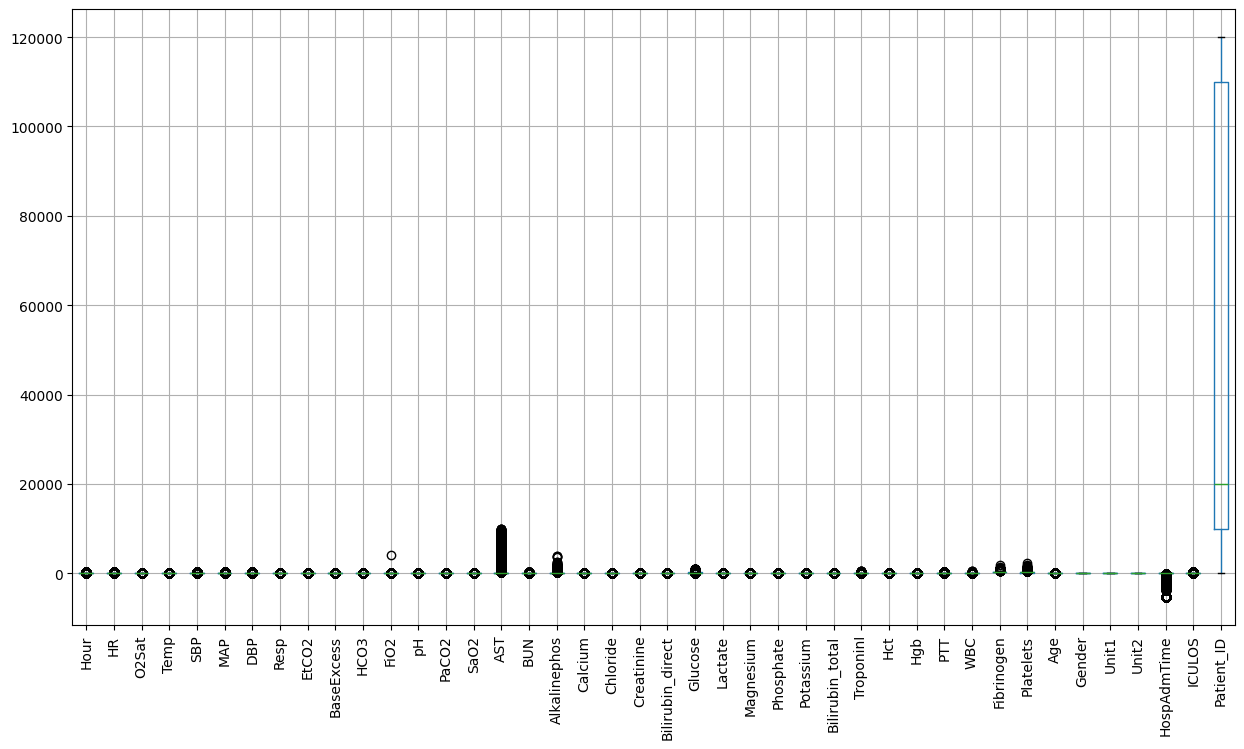

In [123]:
plt.figure(figsize=(15,8))
df.boxplot(rot=90)
plt.show()

In [ ]:
for col in df.columns:
    df.boxplot(column=col)
    plt.title(f"Boxplot - {col}")
    plt.show()

In [125]:
"""Mathematical Analysis on whole data frame before pre-processing"""

'Mathematical Analysis on whole data frame before pre-processing'

In [126]:
df.skew().sort_values(ascending=False)

FiO2                359.335996
WBC                  14.932095
Alkalinephos         10.052137
AST                   6.439521
TroponinI             6.393149
Bilirubin_total       5.267722
Creatinine            4.630426
ICULOS                4.109158
Hour                  4.093620
Bilirubin_direct      4.091971
PTT                   3.458284
Lactate               3.406318
Glucose               2.818303
BUN                   2.531284
Magnesium             2.277447
Platelets             1.840183
Potassium             1.715130
Phosphate             1.682256
Fibrinogen            1.605546
PaCO2                 1.570320
DBP                   1.055223
MAP                   1.050261
Resp                  0.970810
SBP                   0.558909
EtCO2                 0.496015
Hgb                   0.482229
Hct                   0.473127
HR                    0.431251
HCO3                  0.154056
Patient_ID            0.034825
Unit1                 0.013716
BaseExcess           -0.001228
Unit2   

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Hour              1552210 non-null  int64  
 1   HR                1398811 non-null  float64
 2   O2Sat             1349474 non-null  float64
 3   Temp              525226 non-null   float64
 4   SBP               1325945 non-null  float64
 5   MAP               1358940 non-null  float64
 6   DBP               1065656 non-null  float64
 7   Resp              1313875 non-null  float64
 8   EtCO2             57636 non-null    float64
 9   BaseExcess        84145 non-null    float64
 10  HCO3              65028 non-null    float64
 11  FiO2              129365 non-null   float64
 12  pH                107573 non-null   float64
 13  PaCO2             86301 non-null    float64
 14  SaO2              53561 non-null    float64
 15  AST               25183 non-null    float64
 16  BUN        

In [128]:
df.isnull().mean()*100

Hour                 0.000000
HR                   9.882619
O2Sat               13.061119
Temp                66.162697
SBP                 14.576958
MAP                 12.451279
DBP                 31.345887
Resp                15.354559
EtCO2               96.286843
BaseExcess          94.579020
HCO3                95.810618
FiO2                91.665754
pH                  93.069688
PaCO2               94.440121
SaO2                96.549372
AST                 98.377604
BUN                 93.134434
Alkalinephos        98.393194
Calcium             94.116067
Chloride            95.460279
Creatinine          93.904433
Bilirubin_direct    99.807371
Glucose             82.894325
Lactate             97.329872
Magnesium           93.689578
Phosphate           95.986303
Potassium           90.689082
Bilirubin_total     98.509158
TroponinI           99.047745
Hct                 91.145979
Hgb                 92.617558
PTT                 97.055875
WBC                 93.593199
Fibrinogen

In [129]:
"""Column wise analysis for decision making"""

'Column wise analysis for decision making'

In [130]:
# skewness of HR = 0.43 almost normally distributed ..... this data is taken from earlier analysis.
df['HR'].describe()

count    1.398811e+06
mean     8.458144e+01
std      1.732524e+01
min      2.000000e+01
25%      7.200000e+01
50%      8.350000e+01
75%      9.550000e+01
max      2.800000e+02
Name: HR, dtype: float64

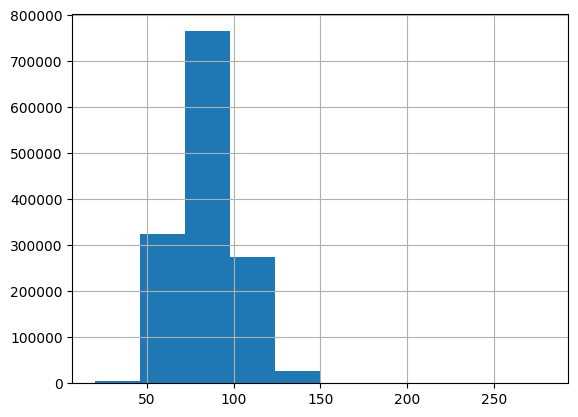

In [131]:
df['HR'].hist()
plt.show()

In [ ]:
# If Threshold=3.5 -> 2_365
# If Threshold=3.0 -> 6_916
# If Threshold=2.5 -> 21_069
# If Threshold=2.75 -> 11_451
count = 0
abs_z_scores = ((df['HR'] - df['HR'].mean()) / df['HR'].std()).abs()
for val in abs_z_scores:
    if val>2.75:
        count+=1
print(count)

11451


In [ ]:
# skewness of O2Sat =  -4.15 Highly negative skewed ..... this data is taken from earlier analysis.
df['O2Sat'].describe()
"""
IQR = 3.5
UPPER_BOUND = 104.75
LOWER_BOUND = 90.75
"""

count    1.349474e+06
mean     9.719395e+01
std      2.936924e+00
min      2.000000e+01
25%      9.600000e+01
50%      9.800000e+01
75%      9.950000e+01
max      1.000000e+02
Name: O2Sat, dtype: float64

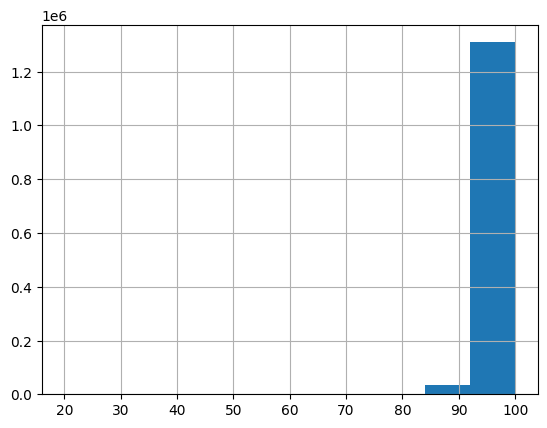

In [ ]:
df['O2Sat'].hist()
plt.show()

In [ ]:
df['O2Sat'].isnull().sum()

np.int64(202736)

In [ ]:
df[df['O2Sat']<=70][['Patient_ID', 'O2Sat']].sort_values(by='Patient_ID')

,Patient_ID,O2Sat
111447,117,53.0
767832,196,61.0
767833,196,63.5
784569,254,51.0
784568,254,39.0
...,...,...
927079,119707,22.0
907579,119734,58.0
946061,119822,68.0
1194292,119928,53.0


In [ ]:
df['MAP'].describe()

count    1.358940e+06
mean     8.240010e+01
std      1.634175e+01
min      2.000000e+01
25%      7.100000e+01
50%      8.000000e+01
75%      9.200000e+01
max      3.000000e+02
Name: MAP, dtype: float64

In [ ]:
df[df['MAP']<30]['MAP'].sum()

np.float64(6499.459999999999)

In [ ]:
df['MAP'].isnull().sum()

np.int64(193270)

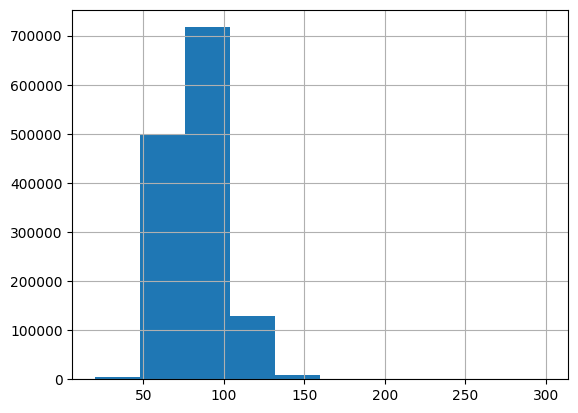

In [ ]:
df['MAP'].hist()
plt.show()

In [ ]:
df[(df['MAP'] < 30) & (df['SBP']>60)][['SBP', 'MAP']]

,SBP,MAP
1173,87.0,29.0
1174,84.0,28.0
12807,129.0,23.5
15796,133.0,20.0
21310,90.0,24.0
...,...,...
759724,73.0,28.0
785901,80.0,27.5
786943,132.0,20.0
787109,119.0,23.0


In [ ]:
df[df['MAP']<30]['MAP']

235       26.5
409       22.5
1173      29.0
1174      28.0
12807     23.5
          ... 
785901    27.5
786246    26.0
786943    20.0
787109    23.0
787332    29.5
Name: MAP, Length: 257, dtype: float64

In [ ]:
df[(df['MAP']<df['DBP']) | (df['MAP']>df['SBP'])][['MAP', 'DBP', 'SBP']]

,MAP,DBP,SBP
8,74.0,91.0,121.0
9,79.0,98.0,120.0
22,75.0,79.0,93.0
23,70.0,88.0,107.0
30,85.0,109.0,115.0
...,...,...,...
1549035,208.0,104.0,112.0
1549538,74.5,79.5,104.5
1550268,64.0,70.0,173.0
1551189,84.0,94.0,118.0


In [ ]:
df['SBP'].describe()

count    1.325945e+06
mean     1.237505e+02
std      2.323156e+01
min      2.000000e+01
25%      1.070000e+02
50%      1.210000e+02
75%      1.380000e+02
max      3.000000e+02
Name: SBP, dtype: float64

In [ ]:
df[(df['SBP']>250) | (df['SBP']<50)]['SBP']

2176        48.0
16372       49.5
18809       39.0
29120       41.0
45825       45.0
           ...  
1513926    262.0
1538339     38.0
1546548    266.0
1547615     30.0
1551070     33.0
Name: SBP, Length: 382, dtype: float64

In [ ]:
df[(df['SBP']<df['DBP']) | (df['SBP']<df['MAP'])][['MAP', 'DBP', 'SBP']]

,MAP,DBP,SBP
1489,220.0,62.0,109.0
1720,106.0,51.5,99.5
1884,146.0,50.5,115.5
2005,134.0,82.0,118.0
2341,160.0,64.0,120.0
...,...,...,...
1544746,286.0,67.0,96.0
1544763,150.0,81.0,140.0
1547269,276.0,268.0,172.0
1548133,168.0,67.0,164.0


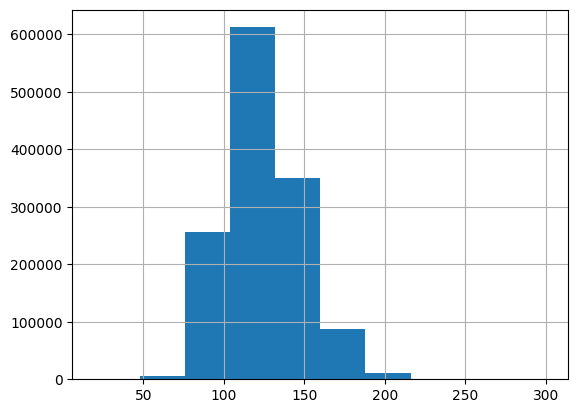

In [ ]:
df['SBP'].hist()
plt.show()

In [ ]:
df['Resp'].describe()

count    1.313875e+06
mean     1.872650e+01
std      5.098194e+00
min      1.000000e+00
25%      1.500000e+01
50%      1.800000e+01
75%      2.150000e+01
max      1.000000e+02
Name: Resp, dtype: float64

In [ ]:
df[(df['Resp']<4) | (df['Resp']>60)]['Resp']

645         3.0
647         3.0
3672        3.0
4524       67.0
12172       2.0
           ... 
1550866     1.0
1550867     2.0
1550869     2.0
1550870     2.0
1551367     1.0
Name: Resp, Length: 1906, dtype: float64

In [ ]:
count = 0
for val in ((df['Resp'] - df['Resp'].median())/df['Resp'].std()):
    if val>2.75 or val<-2.75:
        count += 1

print('Count: ', count)

Count:  20502


In [ ]:
df['ICULOS'].describe()

count    1.552210e+06
mean     2.699499e+01
std      2.900542e+01
min      1.000000e+00
25%      1.100000e+01
50%      2.100000e+01
75%      3.400000e+01
max      3.360000e+02
Name: ICULOS, dtype: float64

In [ ]:
df['ICULOS_diff'] = df.groupby('Patient_ID')['ICULOS'].diff()
df[df['ICULOS_diff'] < 0][['Patient_ID','ICULOS']]

,Patient_ID,ICULOS


In [ ]:
df['HospAdmTime'].describe()

count    1.552202e+06
mean    -5.612512e+01
std      1.622569e+02
min     -5.366860e+03
25%     -4.705000e+01
50%     -6.030000e+00
75%     -4.000000e-02
max      2.399000e+01
Name: HospAdmTime, dtype: float64

In [ ]:
df.groupby(by='Patient_ID')['HospAdmTime'].unique()

Patient_ID
1            [-0.03]
2            [-98.6]
3         [-1195.71]
4            [-8.77]
5            [-0.05]
             ...    
119996       [-6.69]
119997       [-0.02]
119998      [-53.64]
119999      [-10.74]
120000         [0.0]
Name: HospAdmTime, Length: 40336, dtype: object

In [ ]:
df[df['HospAdmTime'].isnull()][['HospAdmTime', 'Patient_ID']]

,HospAdmTime,Patient_ID
580419,NaN,13777
580420,NaN,13777
580421,NaN,13777
580422,NaN,13777
580423,NaN,13777
580424,NaN,13777
580425,NaN,13777
580426,NaN,13777
